<a href="https://qworld.net" target="_blank" align="left"><img src="../../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

# Entangling Feature Maps and Data Re-Uploading

_Prepared by Claudia Zendejas-Morales_

In the previous notebook we studied separable encodings such as angle, amplitude, and basis encoding. Many quantum machine learning models, however, need more than independent single-qubit loading: they need feature maps that can represent **interactions between features**, or they need ways to **reuse the same qubits** when the feature dimension is larger than the available register. This notebook develops those two ideas through entangling feature maps and data re-uploading.

## From local encodings to feature interactions

A separable feature map treats each encoded feature independently. In the common case where one scaled feature angle is assigned to one qubit, a simple local encoding can be written as

$$
U_F^{\mathrm{sep}}(\vec{\varphi}^{\,j}) = \bigotimes_{q=1}^{n} R_y\left(\varphi_q^j\right)
$$

where $q$ labels qubits and $\varphi_q^j$ is the angle associated with the $q$-th feature of sample $j$ after scaling. This map is easy to prepare, but it does not insert any explicit dependence between features carried by different qubits.

An **entangling feature map** adds data-dependent multi-qubit operations. A common pairwise structure is

$$
U_F^{\mathrm{ent}}(\vec{\varphi}^{\,j}) = \left(\prod_{1 \leq q < r \leq n} e^{-i\,\gamma_{qr}\,\varphi_q^j \varphi_r^j Z_q Z_r}\right)
\left(\bigotimes_{q=1}^{n} R_y\left(\varphi_q^j\right)\right)
$$

so the encoded state depends not only on individual features, but also on products such as $\varphi_q^j \varphi_r^j$. This is one of the simplest ways to let the feature map respond to correlations between coordinates before the trainable ansatz even starts.

This idea matters because many learning tasks depend on interactions. If the label changes mostly because two features act together, then a purely separable map may force the later variational circuit to learn that interaction from scratch. An entangling map can move part of that structure directly into the encoding.

<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Optional: what does the interaction product actually do?</b><br>
The factor $\prod_{1 \leq q < r \leq n} e^{-i\,\gamma_{qr}\,\varphi_q^j \varphi_r^j Z_q Z_r}$ is a <b>data-dependent interaction layer</b> placed in front of the separable map $\bigotimes_{q=1}^{n} R_y\left(\varphi_q^j\right)$. The separable part prepares one local rotation per qubit, while each term $e^{-i\,\gamma_{qr}\,\varphi_q^j \varphi_r^j Z_q Z_r}$ adds a two-qubit phase coupling between qubits $q$ and $r$. The strength of that coupling depends on four ingredients at once: the interaction scale $\gamma_{qr}$, the encoded feature on qubit $q$, the encoded feature on qubit $r$, and the operator $Z_q Z_r$ acting jointly on the two qubits.<br><br>
Because of this, the map is no longer only a collection of independent single-qubit rotations. After the local $R_y$ layer creates amplitudes on each qubit, the interaction layer changes the <b>relative phases</b> of the joint basis states according to products such as $\varphi_q^j \varphi_r^j$. So the encoded state starts to depend on <b>pairs of features</b>, not only on one feature at a time. That is the mathematical reason why $U_F^{\mathrm{ent}}(\vec{\varphi}^{\,j})$ can represent correlations that are absent from the purely separable map $U_F^{\mathrm{sep}}(\vec{\varphi}^{\,j})$.<br><br>
A concrete way to implement this kind of joint $Z_q Z_r$ action is with an <b>$R_{ZZ}(\theta)$ gate</b>, or equivalently with a <b>CNOT-$R_z$-CNOT</b> block. For example, the unitary
$$e^{-i\,\theta Z_q Z_r/2}$$
can be realized as
$$\operatorname{CNOT}_{q,r}\,(I \otimes R_z(\theta))\,\operatorname{CNOT}_{q,r}$$
which makes the phrase “acting jointly on qubits $q$ and $r$” more concrete: the phase applied to the two-qubit state depends on the <b>combined computational-basis configuration</b> of those two qubits, not on either qubit separately.
</div>

<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Entangling feature map or entangling ansatz?</b><br>
These are not the same modeling choice. In an <b>entangling feature map</b>, the entangling gates depend on the input sample, so they are part of data loading. In an <b>entangling ansatz</b>, the entangling gates are part of the trainable circuit and depend on variational parameters. In practice, many QML models use both.
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, state_fidelity
from qiskit.circuit.library import z_feature_map, zz_feature_map

To see the geometric effect of an entangling map, it is useful to compare how different samples overlap after encoding. We will encode the same small set of two-feature samples in two ways:

- a local map made only of $R_y$ rotations;
- an entangling map that adds a data-dependent $R_{ZZ}$ block with angle proportional to $\varphi_1 \varphi_2$.

The state fidelity between two encoded samples acts like a simple similarity score: large fidelity means the two encoded states are close, while smaller fidelity means the feature map pushes them farther apart.

Local feature map for sample s1:


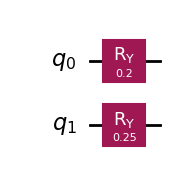


Entangling feature map for sample s1:


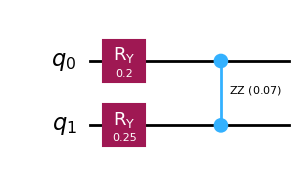

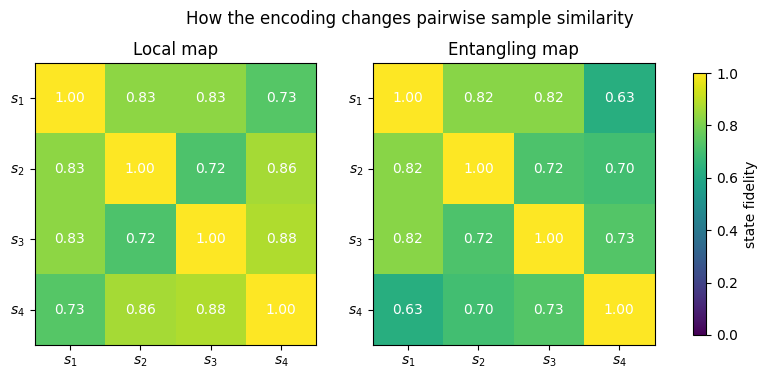

In [2]:
def local_angle_map(phi):
    qc = QuantumCircuit(2)
    for q, angle in enumerate(phi):
        qc.ry(angle, q)
    return qc
def entangling_angle_map(phi, gamma=1.4):
    qc = QuantumCircuit(2)
    for q, angle in enumerate(phi):
        qc.ry(angle, q)
    qc.rzz(gamma * phi[0] * phi[1], 0, 1)
    return qc
def fidelity_matrix(builder, samples):
    n = len(samples)
    matrix = np.zeros((n, n))
    states = [Statevector.from_instruction(builder(sample)) for sample in samples]
    for a in range(n):
        for b in range(n):
            matrix[a, b] = state_fidelity(states[a], states[b])
    return matrix
samples = [
    np.array([0.20, 0.25]),
    np.array([0.25, 1.10]),
    np.array([1.05, 0.30]),
    np.array([1.00, 1.00]),
]
labels = [r"$s_1$", r"$s_2$", r"$s_3$", r"$s_4$"]

local_fidelities = fidelity_matrix(local_angle_map, samples)
entangled_fidelities = fidelity_matrix(lambda x: entangling_angle_map(x, gamma=1.4), samples)

print("Local feature map for sample s1:")
display(local_angle_map(samples[0]).draw("mpl"))
print()
print("Entangling feature map for sample s1:")
display(entangling_angle_map(samples[0], gamma=1.4).draw("mpl"))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, matrix, title in zip(
    axes,
    [local_fidelities, entangled_fidelities],
    ["Local map", "Entangling map"],
):
    image = ax.imshow(matrix, vmin=0.0, vmax=1.0, cmap="viridis")
    ax.set_xticks(range(len(labels)), labels)
    ax.set_yticks(range(len(labels)), labels)
    ax.set_title(title)
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            ax.text(col, row, f"{matrix[row, col]:.2f}", ha="center", va="center", color="white")

fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.85, label="state fidelity")
plt.suptitle("How the encoding changes pairwise sample similarity")
plt.show()


The diagonal entries stay equal to `1`, so the useful comparison is in the **off-diagonal entries**, which measure how similar two *different* encoded samples remain after the feature map is applied. When the $R_{ZZ}$ term is added, some of those entries shift. That is the visual sign that the entangling map is changing the geometry (the pattern of pairwise similarities induced by the encoding). In this example, the pair $(s_2, s_3)$ is worth watching because the two samples exchange the role of the two features, so their overlap can move noticeably once the encoding depends on feature products.

Notice that this comparison uses **<a href="https://en.wikipedia.org/wiki/Fidelity_of_quantum_states">state overlap</a>**, not only raw computational-basis probabilities. We will return to related notions of similarity, measurement, and model outputs in later notebooks of this tutorial.

### Task 1 (coding): How strongly does the entangling term reshape similarity?

Use the example above as a template, but now compare the same sample set under several interaction strengths.

Use the samples

```python
samples_task = [
    np.array([0.20, 0.20]),
    np.array([0.20, 1.00]),
    np.array([1.00, 0.20]),
    np.array([0.95, 0.95]),
    np.array([1.40, 0.60]),
]
```

Build one fidelity matrix for each choice `gamma in [0.0, 0.8, 1.6]`. Plot the three matrices side by side and then compute the absolute difference between the `gamma = 0.0` matrix and the `gamma = 1.6` matrix.

Your goal is to identify which pair of distinct samples changes the most when the entangling term becomes stronger, and to explain in a few sentences what that tells you about data-dependent interactions in the feature map.

<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 1 solution:</b> <a href="02-entangling-feature-maps-and-data-reuploading-solutions.ipynb#task1-solution">Click here for Task 1 solution</a>
</div>

In [3]:
# Task 1 starter
samples_task = [
    np.array([0.20, 0.20]),
    np.array([0.20, 1.00]),
    np.array([1.00, 0.20]),
    np.array([0.95, 0.95]),
    np.array([1.40, 0.60]),
]
labels_task = [r"$t_1$", r"$t_2$", r"$t_3$", r"$t_4$", r"$t_5$"]
gammas = [0.0, 0.8, 1.6]

# TODO:
# 1. build one fidelity matrix per gamma
# 2. plot the matrices side by side
# 3. compute the absolute difference between gamma=0.0 and gamma=1.6
# 4. ignore the diagonal and identify the pair with the largest change
# 5. explain what changed and why

## The ZZ feature map

A widely used family of entangling feature maps is based on **second-order Pauli-$Z$ evolution**, usually referred to as a **ZZ feature map**. For a sample $\vec{x}^{\,j} \in \mathbb{R}^d$, assume that the first $n$ scaled features have been converted into angles $\varphi_1^j, \dots, \varphi_n^j$. A ZZ-style encoding can then be described as a composition

$$
U_{\mathrm{ZZ}}(\vec{\varphi}^{\,j}) = U_{\mathrm{ZZ}}^{(2)}(\vec{\varphi}^{\,j})\,U_{\mathrm{ZZ}}^{(1)}(\vec{\varphi}^{\,j})\,H^{\otimes n}
$$

where

$$
U_{\mathrm{ZZ}}^{(1)}(\vec{\varphi}^{\,j}) = \prod_{q=1}^{n} P\!\left(2\varphi_q^j\right)
$$

loads single-feature phase information, and

$$
U_{\mathrm{ZZ}}^{(2)}(\vec{\varphi}^{\,j}) = \prod_{1 \leq q < r \leq n} \exp\!\left(-i\,\gamma_{qr}\,\varphi_q^j \varphi_r^j Z_q Z_r\right)
$$

adds pairwise interactions between qubits $q$ and $r$.

The pairwise block above is the Hamiltonian-style expression of the interaction. In the circuit decomposition used in many ZZ-style constructions, the same idea is implemented through controlled phases. One convenient formal description is

$$
U_{qr}^{\mathrm{int}}(\vec{\varphi}^{\,j}) = \operatorname{CNOT}_{q,r}\,\Bigl(I \otimes P\!\left(2(\pi - \varphi_q^j)(\pi - \varphi_r^j)\right)\Bigr)\,\operatorname{CNOT}_{q,r}
$$

so that the full interaction layer can be written as

$$
U_{\mathrm{ZZ}}^{(2)}(\vec{\varphi}^{\,j}) = \prod_{1 \leq q < r \leq n} U_{qr}^{\mathrm{int}}(\vec{\varphi}^{\,j})
$$

This makes the ZZ map a practical extension of angle encoding: it remains close to hardware-friendly single-qubit rotations and controlled entanglers, while introducing feature correlations directly into the data-loading circuit. It is one of the most common structured feature maps in variational classification and kernel-based QML workflows.

<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="./images/feature-map-zz-feature-map.png" alt="ZZ feature map" width="900"/>
</p>

In this kind of circuit, the Hadamard layer prepares each qubit to become sensitive to phase, the single-qubit phase gates load individual scaled features, and the entangling blocks add pairwise phases that depend on two features at once. The structure is still shallow enough to be practical in small examples, but it is already much richer than a purely separable angle map.

<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Why can a phase-based map still matter for learning?</b><br>
A ZZ feature map stores much of its information in relative phases. Those phases may not be obvious in immediate computational-basis probabilities, but they become physically relevant once later gates, interference, or different measurement bases convert phase differences into observable quantities. That is why phase-based feature maps can still reshape similarity, kernels, and classification boundaries.
</div>

The official Qiskit circuit library includes both `z_feature_map` and `zz_feature_map`. Comparing them side by side is a simple way to see what extra structure is introduced when pairwise entangling phases are turned on.

Z feature map:


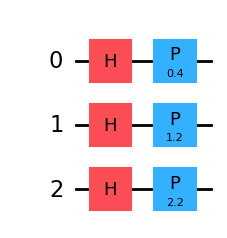

ZZ feature map:


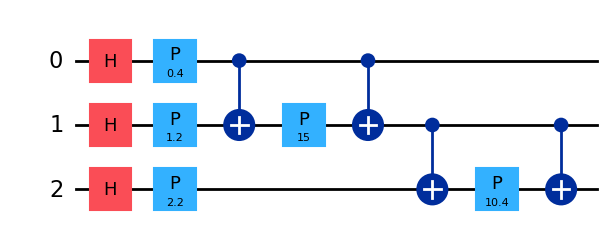

z_feature_map
depth: 2
operation counts: {'u': 6}
zz_feature_map
depth: 8
operation counts: {'u': 8, 'cx': 4}


In [4]:
features = [0.20, 0.60, 1.10]

z_map = z_feature_map(feature_dimension=len(features), reps=1)
zz_map = zz_feature_map(feature_dimension=len(features), reps=1, entanglement="linear")

z_encoded = z_map.assign_parameters(features)
zz_encoded = zz_map.assign_parameters(features)

print("Z feature map:")
display(z_encoded.draw("mpl"))
print("ZZ feature map:")
display(zz_encoded.draw("mpl"))

for name, circuit in [("z_feature_map", z_encoded), ("zz_feature_map", zz_encoded)]:
    decomposed = circuit.decompose()
    print(f"{name}")
    print("depth:", decomposed.depth())
    print("operation counts:", dict(decomposed.count_ops()))

The `z_feature_map` loads only single-feature phases, whereas `zz_feature_map` inserts explicit two-qubit interactions. That usually increases depth and the number of entangling gates, but it also gives the encoding access to pairwise feature structure. This is the central tradeoff: richer geometry usually costs more circuit resources.

### Task 2 (coding): How expensive does the ZZ map become as we scale it up?

Use the Qiskit circuit-library implementation to compare four ZZ-style encodings of the same four-feature sample

```python
features = [0.20, 0.50, 0.90, 1.10]
```

Construct and analyze the following circuits:

- `reps=1`, `entanglement="linear"`
- `reps=1`, `entanglement="full"`
- `reps=2`, `entanglement="linear"`
- `reps=2`, `entanglement="full"`

For each circuit, assign the parameters, decompose once, and record the depth and operation counts. Then write a short conclusion explaining which option you would keep under a shallow-circuit budget and which option you would keep if modeling pairwise correlations mattered more than circuit depth.

Official references that may help:
- <a href="https://quantum.cloud.ibm.com/docs/en/guides/circuit-library">Qiskit circuit library guide</a>
- <a href="https://quantum.cloud.ibm.com/docs/en/api/qiskit/circuit_library">Qiskit circuit-library API</a>

<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 2 solution:</b> <a href="02-entangling-feature-maps-and-data-reuploading-solutions.ipynb#task2-solution">Click here for Task 2 solution</a>
</div>

In [5]:
# Task 2 starter
features = [0.20, 0.50, 0.90, 1.10]
configs = [
    (1, "linear"),
    (1, "full"),
    (2, "linear"),
    (2, "full"),
]

# TODO:
# 1. loop over the configurations
# 2. build the corresponding zz_feature_map
# 3. assign the feature values
# 4. decompose once and record depth plus operation counts
# 5. summarize your conclusion for shallow hardware and for richer correlations

### Task 3 (optional, coding): Build a ZZ-style feature map in PennyLane

Use the formal description of the ZZ feature map from this notebook and implement a small **PennyLane** version by hand. The goal is not to rely on a prebuilt class, but to translate the circuit idea into PennyLane operations.

Work with three qubits and the sample

```python
features = np.array([0.20, 0.60, 1.10])
```

Build a QNode that does the following:

- apply `qml.Hadamard` on each qubit;
- apply a local phase `qml.PhaseShift(2 * features[q])` on each qubit;
- for the linear pairs `(0, 1)` and `(1, 2)`, apply a `CNOT-PhaseShift-CNOT` block with angle `2 * (np.pi - features[q]) * (np.pi - features[r])`;
- return the full quantum state with `qml.state()`.

Then draw the circuit for the sample above; evaluate the encoded state for that sample and for
  ```python
  features_b = np.array([0.25, 1.00, 0.55])
  ```
and compute the state overlap `|<psi(features) | psi(features_b)>|^2` with NumPy.

Official references that may help:
- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.qnode.html"><code>qml.qnode</code></a>
- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.Hadamard.html"><code>qml.Hadamard</code></a>
- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.PhaseShift.html"><code>qml.PhaseShift</code></a>
- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.CNOT.html"><code>qml.CNOT</code></a>
- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.state.html"><code>qml.state</code></a>

<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 3 solution:</b> <a href="02-entangling-feature-maps-and-data-reuploading-solutions.ipynb#task3-solution">Click here for Task 3 solution</a>
</div>

In [6]:
# Task 3 starter
import pennylane as qml

features = np.array([0.20, 0.60, 1.10])
features_b = np.array([0.25, 1.00, 0.55])
dev_zz = qml.device("default.qubit", wires=3)

# TODO:
# 1. define a QNode that implements a linear ZZ-style feature map on 3 qubits
# 2. use Hadamard, PhaseShift, and CNOT gates explicitly
# 3. return qml.state()
# 4. draw the circuit for 'features'
# 5. evaluate the states for 'features' and 'features_b'
# 6. compute the overlap |<psi(features)|psi(features_b)>|^2

## Data re-uploading

Entangling feature maps enrich the encoding by coupling qubits. **Data re-uploading** enriches the encoding in a different way: it loads the same classical sample more than once, with trainable quantum processing in between. For a sample $\vec{x}^{\,j}$ and a feature map $U_F(\vec{x}^{\,j})$, a layered re-uploading architecture can be defined recursively by

$$
|\psi_0\rangle = |0\rangle^{\otimes n}
$$

and, for $s = 1, \dots, S$,

$$
|\psi_{s}(\vec{x}^{\,j}, \boldsymbol{\theta}_1, \dots, \boldsymbol{\theta}_{s})\rangle
=
V_{s}(\boldsymbol{\theta}_{s})\,U_F(\vec{x}^{\,j})\,|\psi_{s-1}(\vec{x}^{\,j}, \boldsymbol{\theta}_1, \dots, \boldsymbol{\theta}_{s-1})\rangle
$$

Here each $\boldsymbol{\theta}_{s}$ is the full parameter vector of the trainable block $V_{s}$ at re-uploading stage $s$, while $\boldsymbol{\theta}$ without a subscript denotes the complete collection of trainable parameters of the model, that is, $\boldsymbol{\theta} = (\boldsymbol{\theta}_1, \dots, \boldsymbol{\theta}_S)$.

The final state is therefore

$$
|\psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta})\rangle
=
|\psi_{S}(\vec{x}^{\,j}, \boldsymbol{\theta}_1, \dots, \boldsymbol{\theta}_{S})\rangle
=
V_S(\boldsymbol{\theta}_S) U_F(\vec{x}^{\,j}) \cdots V_2(\boldsymbol{\theta}_2) U_F(\vec{x}^{\,j}) V_1(\boldsymbol{\theta}_1) U_F(\vec{x}^{\,j}) |0\rangle^{\otimes n}
$$

If the model is read through an observable $O$, the scalar output takes the form

$$
f(\vec{x}^{\,j}, \boldsymbol{\theta}) = \langle \psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta}) | O | \psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta}) \rangle
$$

The same sample $\vec{x}^{\,j}$ is injected several times, but the state is no longer the same after each upload because trainable blocks $V_1, V_2, \dots, V_S$ have changed it in between. This lets a small register generate much richer input-output dependencies than a single upload would allow.

Conceptually, re-uploading trades **qubits** for **depth**. Instead of asking for more qubits to carry more classical structure at once, the model reuses the existing qubits across multiple encoding stages.


<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="./images/feature-map-data-reuploading-schematic.png" alt="Data re-uploading schematic" width="700"/>
</p>

The important point is that the same input sample $\vec{x}^{\,j}$ reappears several times in the circuit. The model is not only “seeing more parameters”; it is repeatedly intertwining the same data with trainable quantum transformations.

<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Why does re-uploading need trainable processing in between?</b><br>
If we applied the same encoding block repeatedly with no nontrivial operation between copies, the result could often collapse to a single effective encoding. For example, two consecutive rotations around the same axis combine into one larger rotation. Re-uploading becomes interesting when intermediate trainable blocks change the state before the next upload arrives.
</div>

One-upload circuit at x = 0.5:
0: ──AngleEmbedding(M0)──Rot(0.40,-0.60,0.20)─┤  <Z>

M0 = 
[0.5]
Two-upload circuit at x = 0.5:
0: ──AngleEmbedding(M0)──Rot(0.40,-0.60,0.20)──AngleEmbedding(M0)──Rot(1.10,-0.30,0.70)─┤  <Z>

M0 = 
[0.5]


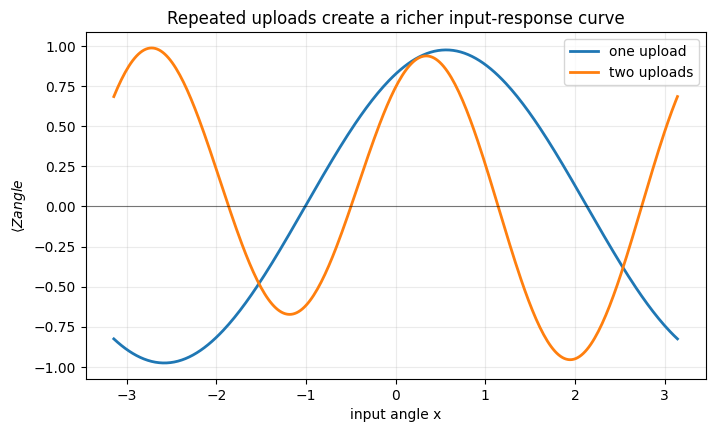

In [7]:
import pennylane as qml
dev = qml.device("default.qubit", wires=1)

@qml.qnode(dev)
def one_upload_model(x, theta):
    qml.AngleEmbedding(features=[x], wires=[0], rotation="Y")
    qml.Rot(*theta[:3], wires=0)
    return qml.expval(qml.PauliZ(0))

@qml.qnode(dev)
def two_upload_model(x, theta):
    qml.AngleEmbedding(features=[x], wires=[0], rotation="Y")
    qml.Rot(*theta[:3], wires=0)
    qml.AngleEmbedding(features=[x], wires=[0], rotation="Y")
    qml.Rot(*theta[3:6], wires=0)
    return qml.expval(qml.PauliZ(0))

theta_one = np.array([0.40, -0.60, 0.20])
theta_two = np.array([0.40, -0.60, 0.20, 1.10, -0.30, 0.70])

print("One-upload circuit at x = 0.5:")
print(qml.draw(one_upload_model)(0.5, theta_one))
print("Two-upload circuit at x = 0.5:")
print(qml.draw(two_upload_model)(0.5, theta_two))

x_grid = np.linspace(-np.pi, np.pi, 300)
one_values = np.array([one_upload_model(x, theta_one) for x in x_grid])
two_values = np.array([two_upload_model(x, theta_two) for x in x_grid])

plt.figure(figsize=(8, 4.5))
plt.plot(x_grid, one_values, label="one upload", linewidth=2)
plt.plot(x_grid, two_values, label="two uploads", linewidth=2)
plt.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
plt.xlabel("input angle x")
plt.ylabel(r"$\langle Z angle$")
plt.title("Repeated uploads create a richer input-response curve")
plt.grid(alpha=0.25)
plt.legend()
plt.show()


Even on one qubit, the two-upload model can produce a visibly richer dependence on $x$ than the one-upload model. That does not prove better learning by itself, but it does show why re-uploading is attractive: the model family becomes more flexible without adding more qubits.

The price is depth. Each extra upload means more gates, more trainable parameters, and more opportunities for noise and optimization difficulties.

### Task 4 (coding): Add a third upload and quantify the extra oscillatory structure

Use the PennyLane example above as a template and build a **three-upload** version of the same model. Keep one qubit, keep `rotation="Y"` inside `qml.AngleEmbedding`, and use one `qml.Rot` block after each upload.

Use the parameter vector

```python
theta_three = np.array([0.40, -0.60, 0.20, 1.10, -0.30, 0.70, -0.80, 0.50, 1.20])
```

Evaluate the one-upload, two-upload, and three-upload models on the same grid `x_grid = np.linspace(-np.pi, np.pi, 400)`. Plot the three curves together and then count how many times the **discrete slope** changes sign along each curve. In practice, this means computing finite differences and checking how often the response goes from increasing to decreasing or vice versa.

Use that count only as a simple diagnostic of oscillatory structure, not as a formal complexity measure. The goal is to test whether the third upload introduces additional structure in the response.

Official references that may help:
- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.AngleEmbedding.html"><code>qml.AngleEmbedding</code></a>
- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.qnode.html"><code>qml.qnode</code></a>
- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.Rot.html"><code>qml.Rot</code></a>
- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.expval.html"><code>qml.expval</code></a>

<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 4 solution:</b> <a href="02-entangling-feature-maps-and-data-reuploading-solutions.ipynb#task4-solution">Click here for Task 4 solution</a>
</div>

In [8]:
# Task 4 starter
theta_three = np.array([0.40, -0.60, 0.20, 1.10, -0.30, 0.70, -0.80, 0.50, 1.20])
x_grid = np.linspace(-np.pi, np.pi, 400)

# TODO:
# 1. define a three_upload_model QNode following the same pattern
# 2. evaluate the one-, two-, and three-upload models on x_grid
# 3. plot the three curves together
# 4. implement a helper that counts slope sign changes (turning points)
# 5. compare the three counts and interpret them

## Practical guidance

Entangling feature maps and data re-uploading solve different modeling problems. An entangling map is natural when you already have enough qubits to host the relevant features and you want the encoding itself to react to correlations between them. Re-uploading is natural when qubits are scarce and you would rather pay with depth than with a larger register.

In practice, these ideas can also be combined: one can re-upload a sample several times and still use entangling blocks inside each upload. The difficulty is that every extra source of expressivity also increases depth, calibration demands, and the chance of trainability problems. This is why scaling, normalization, and hardware-aware circuit design remain essential even when the encoding is expressive in principle.

### Task 5 (design): Choose between more entanglement and more uploads

For each scenario below, choose the most reasonable strategy among **plain angle encoding**, **an entangling feature map such as a ZZ-style map**, **data re-uploading**, or **a hybrid**. Justify each choice in about 3 to 5 sentences.

Scenario A:
- 6 continuous features.
- Hardware budget: 6 qubits.
- Entangling gates are available, but the circuit must stay shallow.
- The task seems to depend on pairwise correlations between features.

Scenario B:
- 18 continuous features.
- Hardware budget: 4 qubits.
- Circuit depth is acceptable on a simulator, but qubits are scarce.
- You suspect the model needs several nonlinear transformations of the same inputs.

Scenario C:
- 4 continuous features.
- Hardware budget: 4 qubits.
- Two-qubit gates are noticeably noisy.
- You still want some expressive power beyond a single local upload.

Your answer should make clear what resource is being traded in each case and why.

<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 5 solution:</b> <a href="02-entangling-feature-maps-and-data-reuploading-solutions.ipynb#task5-solution">Click here for Task 5 solution</a>
</div>

## Closing remarks

A feature map does more than place numbers into gates. It shapes the geometry of the problem seen by the variational model. Entangling feature maps do so by inserting data-dependent correlations between qubits, while data re-uploading does so by letting a small register interact with the same sample several times.

The next notebook turns to the trainable side of the architecture and studies ansatz families, expressivity, and the depth-versus-trainability tradeoff.